<small>
Copyright (c) 2017 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning From Basics to Practice
## by Andrew Glassner, https://dlbasics.com, http://glassner.com
------
## Chapter 23: Keras
### Notebook 9: Improving the model

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical  # Исправленный импорт
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping

import h5py
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import backend as keras_backend
keras_backend.set_image_data_format('channels_last')


In [ ]:
# from keras.datasets import mnist
# from keras.models import Sequential
# from keras.layers import Dense
# from keras.utils import np_utils
# from keras.models import load_model
# from keras.callbacks import EarlyStopping
# from keras.optimizers import Adam
# from keras.layers import Dropout
# from keras.constraints import maxnorm
# import h5py
# import numpy as np

# from keras import backend as keras_backend
# keras_backend.set_image_data_format('channels_last')

In [ ]:
# Make a File_Helper for saving and loading files.

# save_files = True

# import os, sys, inspect
# current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
# sys.path.insert(0, os.path.dirname(current_dir)) # path to parent dir
# from DLBasics_Utilities import File_Helper
# file_helper = File_Helper(save_files)

In [4]:
# Load and process the MNIST data

random_seed = 42

# load the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
image_height = X_train.shape[1]
image_width = X_train.shape[2]
number_of_pixels = image_height * image_width

# cast the sample data to the current Keras floating-point type
X_train = keras_backend.cast_to_floatx(X_train)
X_test = keras_backend.cast_to_floatx(X_test)

# scale data to range [0, 1]
X_train /= 255.0
X_test /= 255.0

# save labels in their non-one-hot form
original_y_train = np.copy(y_train)
original_y_test = np.copy(y_test)

# replace label data with one-hot encoded versions
number_of_classes = 1 + max(np.append(y_train, y_test))
y_train = to_categorical(y_train, number_of_classes)
y_test = to_categorical(y_test, number_of_classes)

# reshape to 2D grid, one line per image
X_train = X_train.reshape(X_train.shape[0], number_of_pixels)
X_test = X_test.reshape(X_test.shape[0], number_of_pixels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
model = Sequential([Input(shape=(28*28,)),
                    Dense(32, activation='relu', kernel_constraint=max_norm(3)),
                    Dropout(0.2),
                    Dense(32, activation='relu', kernel_constraint=max_norm(3)),
                    Dropout(0.2),
                    Dense(10, activation='softmax')]
)
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
)
early_stopper = EarlyStopping(monitor='val_loss',
                              patience=10,
                              verbose=1,
                              restore_best_weights = True,
                              min_delta=0
)
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=256,
                    verbose=2,
                    callbacks=[early_stopper]
)


Epoch 1/50
235/235 - 2s - 9ms/step - accuracy: 0.7005 - loss: 0.9454 - val_accuracy: 0.9077 - val_loss: 0.3322
Epoch 2/50
235/235 - 1s - 3ms/step - accuracy: 0.8677 - loss: 0.4479 - val_accuracy: 0.9259 - val_loss: 0.2524
Epoch 3/50
235/235 - 1s - 3ms/step - accuracy: 0.8906 - loss: 0.3731 - val_accuracy: 0.9330 - val_loss: 0.2242
Epoch 4/50
235/235 - 1s - 3ms/step - accuracy: 0.9001 - loss: 0.3358 - val_accuracy: 0.9422 - val_loss: 0.2028
Epoch 5/50
235/235 - 1s - 3ms/step - accuracy: 0.9087 - loss: 0.3060 - val_accuracy: 0.9437 - val_loss: 0.1914
Epoch 6/50
235/235 - 1s - 3ms/step - accuracy: 0.9155 - loss: 0.2858 - val_accuracy: 0.9477 - val_loss: 0.1796
Epoch 7/50
235/235 - 1s - 5ms/step - accuracy: 0.9191 - loss: 0.2709 - val_accuracy: 0.9520 - val_loss: 0.1695
Epoch 8/50
235/235 - 1s - 3ms/step - accuracy: 0.9224 - loss: 0.2615 - val_accuracy: 0.9538 - val_loss: 0.1596
Epoch 9/50
235/235 - 1s - 4ms/step - accuracy: 0.9255 - loss: 0.2496 - val_accuracy: 0.9543 - val_loss: 0.1567
E

In [10]:
# A little utility to draw accuracy and loss plots
import matplotlib.pyplot as plt

def plot_accuracy_and_loss(history, plot_title, filename):
    xs = range(len(history.history['accuracy']))
    # manually change legend location to 'best' when the locations
    # here don't look good.

    plt.figure(figsize=(10,3))
    plt.subplot(1, 2, 1)
    plt.plot(xs, history.history['accuracy'], label='train')
    plt.plot(xs, history.history['val_accuracy'], label='validation')
    plt.legend(loc='lower left')
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.title(plot_title+', Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(xs, history.history['loss'], label='train')
    plt.plot(xs, history.history['val_loss'], label='validation')
    plt.legend(loc='upper left')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title(plot_title+', Loss')

    #plt.tight_layout()
    # file_helper.save_figure(filename)
    plt.show()

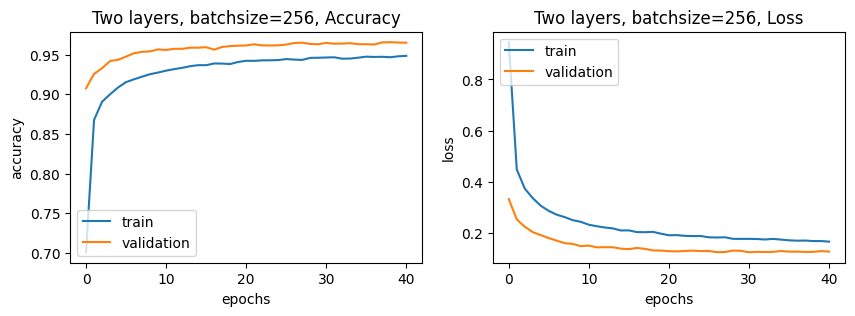

In [13]:
plot_accuracy_and_loss(history, 'Two layers, batchsize=256', 'two-layers-batch-256')